(sec:va-continue)=
# Variabili aleatorie continue

Di seguito formalizziamo e generalizziamo i nuovi concetti che sono emersi nel
paragrafo precedente. In particolare, partiamo dalla definizione di _variabile
aleatoria continua_.

```{margin}
Come indicato nella {prf:ref}`def:dominio`, per dominio si intende qui
l'insieme delle specificazioni di una variabile aleatoria.
```
````{prf:definition} Variabile aleatoria continua
:label: def:va-continua

Una variabile aleatoria $X$ si dice _continua_ quando il suo dominio $D_X$ è
un insieme continuo.
````

Il calcolo di probabilità di eventi collegati a una variabile aleatoria
continua viene normalmente fatto utilizzando la relativa funzione di
ripartizione, che è definita esattamente come nel caso di una variabile
aleatoria discreta, oppure in termini della funzione di densità introdotta
in modo informale nel paragrafo precedente. Per definire questo concetto in
modo più preciso, notiamo innanzitutto che per $x \in \mathbb R$ e
$\Delta x \in \mathbb R^+$, è sempre possibile considerare l'evento
$X \in (x, x + \Delta x]$ che si verifica quando $X$ assume valori
nell'intervallo che ha $x$ come estremo sinistro e $\Delta x$ come ampiezza.
Infatti, in base alla {prf:ref}`def:variabile-aleatoria` sappiamo che

```{math}
X^{-1}((-\infty, a]) = \{ w \in \Omega \text{ tale che } X(\omega) \leq a \}
```

è sempre contenuto nell'algebra degli eventi $\mathsf A$ che stiamo
considerando, e siccome

```{math}
X^{-1}((x, x + \Delta x]) = X^{-1}((-\infty, x + \Delta x]) \,\backslash\,
                          X^{-1}((-\infty, x]) \,,
```

il {prf:ref}`teo-chiusura-algebra-eventi` ci permette di concludere che anche
$X^{-1}((x, x + \Delta x])$ è contenuto in $\mathsf A$. Risulta dunque ben
definito il rapporto

```{math}
\frac{\mathbb P(X \in (x, x + \Delta x])}{\Delta x} \,,
```

così come il suo limite per $\Delta x \to 0$, che permette di definire la
la densità di probabilità in $x$.

````{prf:definition} Funzione di densità
:label: def:densita

La _funzione di densità_ di una variabile aleatoria continua $X$ è una
funzione $f_X: \mathbb R \rightarrow \mathbb R^+$ che associa a ogni argomento
$x \in \mathbb R$ il valore

```{math}
f_X(x) =
\lim_{\Delta x \to 0}\frac{\mathbb P(X \in (x, x + \Delta x])}{\Delta x} \,,
```

che indica la densità della probabilità che $X$ assuma valori a destra di $x$.
````

Siccome

\begin{align*}
\mathbb P(X \in (x, x + \Delta x]) &= \mathbb P(x < X \leq x + \Delta x) \\
                                   &= F_X(x + \Delta x) - F(x) \,,
\end{align*}

si verifica facilmente che per ogni $x \in \mathbb R$ il valore $f_X(x)$
equivale al limite del rapporto incrementale di $F$ quando l'ampiezza del
relativo intervallo tende a zero, e quindi la funzione di densità di una
variabile aleatoria continua $X$ coincide con la derivata prima della sua
funzione di ripartizione.

````{prf:example}
Le funzioni di ripartizione e di densità della variabile aleatoria continua
$X$ introdotta nel paragrafo precedente sono definite rispettivamente nel
modo seguente:

```{math}
F_X(x) = x \mathrm I_{[0, 1]}(x) + \mathrm I_{(1, +\infty)}(x)
```

e

```{math}
f_X(x) = \mathrm I_{[0, 1]}(x) \,,
```

dunque si verifica facilmente che $F_X' =f_X$.

````

La funzione di ripartizione è quindi una primitiva della funzione di
densità, e il teorema fondamentale del calcolo integrale [^tfci]
implica che per ogni $a, b \in \mathbb R$ tali che $a < b$ si ha

```{math}
\int_a^b f_X(x) \,\mathrm d x = F_X(b) - F_X(a) 
                              = \mathbb P(a \leq X \leq b) \,.
```

Considerando il limite per $b \rightarrow -\infty$ si ottiene, analogamente,
che $\mathbb P(X \leq x) = \int_{-\infty}^x f_X(x) \, \mathrm d x$. Più in
generale, dato un qualsiasi insieme $A$ esprimibile in termini di operazioni
fondamentali effettuate su intervalli, varrà dunque

```{math}
\mathrm P(X \in A) = \int_A f_X(x) \, \mathrm d x \,,
```

e quindi la probabilità $\mathbb P(X \in A)$ è interpretabile in termini
dell'area contenuta tra l'asse delle ascisse e il grafico della funzione di
densità di $X$ ristretta all'insieme $A$, come esemplificato in
{numref}`fig:pdf-interpretation`.

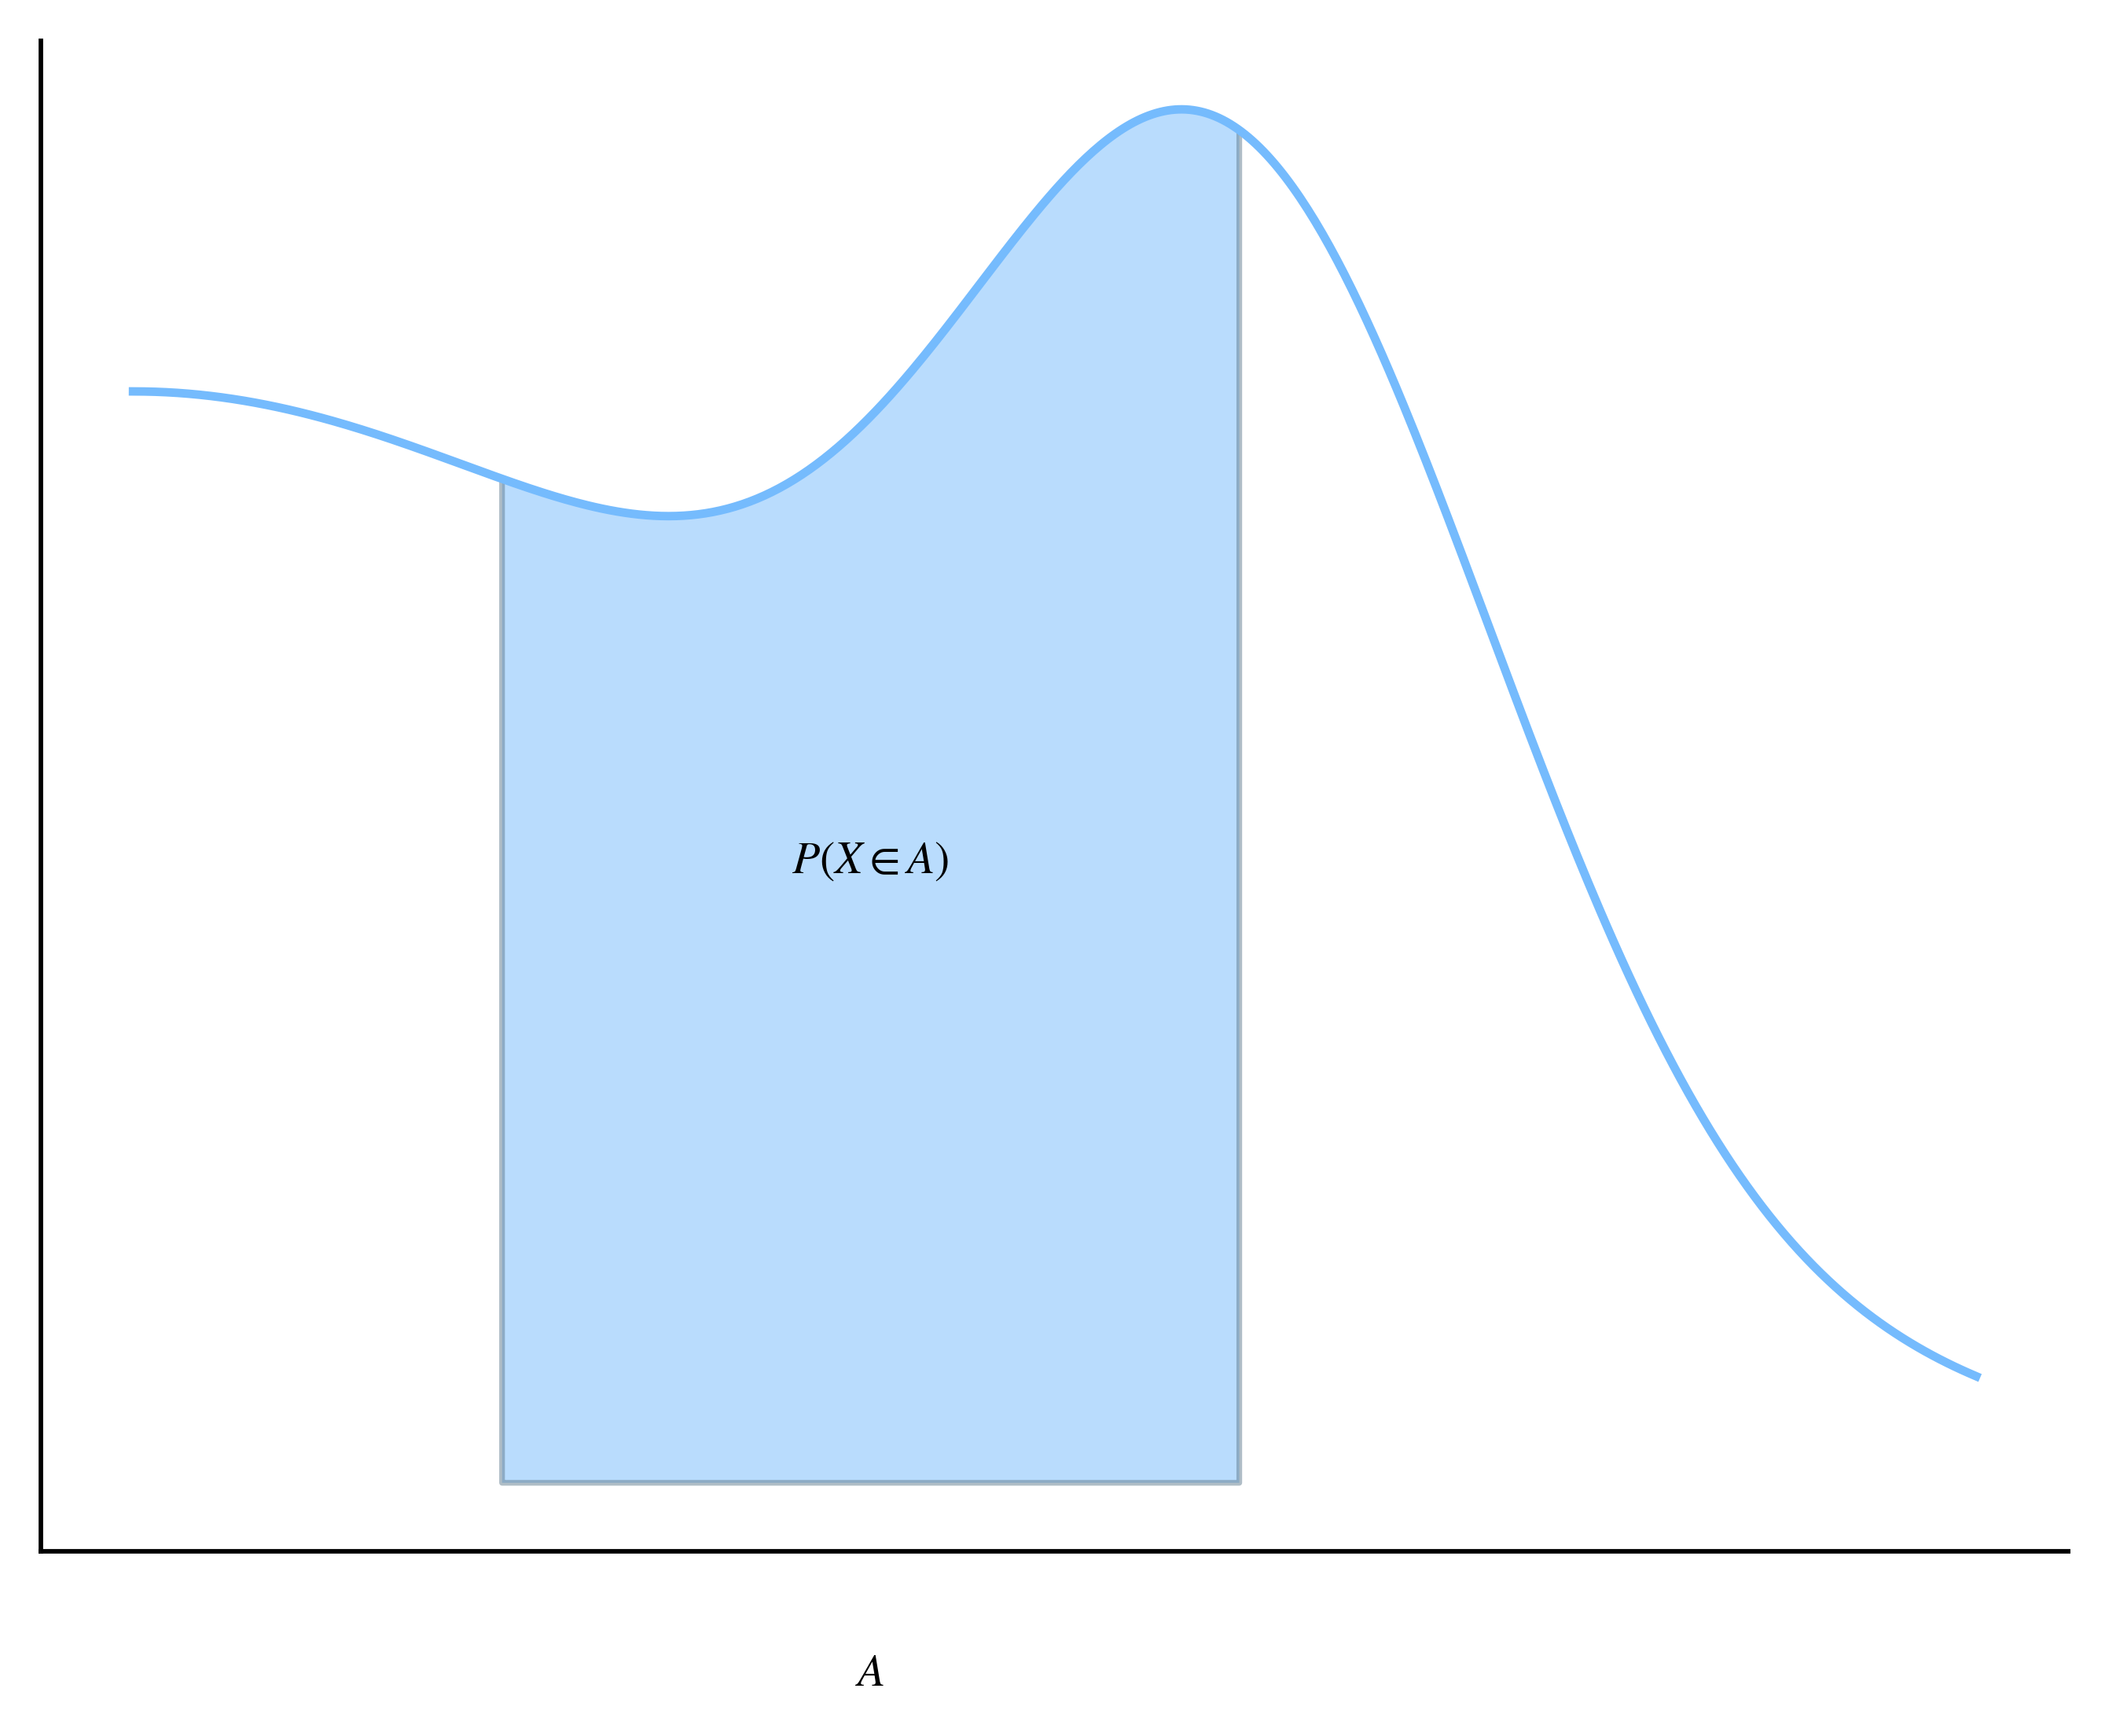

In [1]:
import matplotlib.pyplot as plt
from myst_nb import glue
import numpy as np
from scipy.stats import norm

plt.rcParams.update({
    'font.size': 8,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

# to ensure that pdf is a probability density
Z = norm()
norm_factor = (1 - Z.cdf(3 * 2**0.5))/ 2**0.5 + 5**0.5

def pdf(x):
    return (1.2 * np.exp(-.1*(x)**2) + np.exp(-(x-3)**2)) / norm_factor

fig, ax = plt.subplots()
x = np.linspace(-0, 5, 500)
y = pdf(x)

x_filled = np.linspace(1, 3, 500)
y_filled = pdf(x_filled)

ax.fill_between(x_filled, y_filled, alpha=0.5)
ax.plot(x, y)

ax.text(2, -.1, r'$A$', horizontalalignment='center')
ax.text(2, 0.3, '$P(X \\in A)$', horizontalalignment='center')

ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)

ax.xaxis.set_major_formatter(plt.NullFormatter())
ax.yaxis.set_major_formatter(plt.NullFormatter())
ax.tick_params(axis=u'both', which=u'both',length=0)
plt.show()

glue("pdf-interpretation", fig, display=False)

```{glue:figure} pdf-interpretation
:figwidth: 100%
:name: fig:pdf-interpretation

Visualizzazione dell'interpretazione geometrica della funzione di
densità di probabilità di una variabile aleatoria continua.
```

Il concetto di valore atteso di una variabile aleatoria continua o di una
sua funzione si ottiene estendendo la {prf:ref}`def:valore-atteso-discreto`.

```{margin}
Anche in questo caso non 
```
````{prf:definition} Valore atteso di una variabile aleatoria continua
:label: def:valore-atteso-continuo

Il _valore atteso_ di una variabile aleatoria continua $X$ è definito come

```{math}
\mathbb E(X) = \int_{-\infty}^{+\infty} x f_X(x) \, \mathrm d x \,,
```

nel caso in cui l'integrale converga, e risulta indefinito altrimenti.
Analogamente, il valore atteso di una funzione misurabile $g$ applicata a
una variabile aleatoria continua $X$ è uguale a

```{math}
\mathbb E(g(X)) = \int_{-\infty}^{+\infty} g(x) f_X(x) \, \mathrm d x
```

quando l'integrale converge ed è indefinito negli altri casi.
````

Tutte le definizioni introdotte per le variabili aleatorie discrete che
coinvolgono il loro valore atteso o valori attesi di loro funzioni rimangono
valide anche per le variabili continue. Per esempio, la varianza di una
variabile aleatoria continua $X$ sarà ancora definita come il valore atteso
del suo scarto quadratico da $\mathbb E(X)$, la deviazione standard
continua a essere uguale alla radice quadrata della varianza e così via.


````{prf:example}
Il valore atteso della variabile aleatoria $X$ introdotta nel paragrafo
precedente è

```{math}
\mathbb E(X) = \int_{-\infty}^{+\infty} x \, \mathrm I_{[0, 1]}(x)
               \, \mathrm d x
             = \int_0^1 x \, \mathrm d x
             = \left. \frac{x^2}{2} \right|_0^1
             = \frac{1}{2} \enspace,
```

e analoamente la sua varianza è uguale a

\begin{multline*}
\mathrm{Var}(X) = \mathbb E \left( \left( X - \frac{1}{2} \right)^2 \right)
                = \int_0^1  \left( x - \frac{1}{2} \right)^2 \mathrm d x \\
                = \int_{-\frac{1}{2}}^{\frac{1}{2}} y^2 \, \mathrm d y
                = \left. \frac{y^3}{3} \right|_{-\frac{1}{2}}^{\frac{1}{2}}
                = \frac{1}{12} \enspace.
\end{multline*}
````

Anche tutte le definzioni già introdotte e definite in termini di probabilità
calcolate su una variabile aleatoria rimangono invariate nel caso continuo,
sebbene la continuità del supporto permetta in alcuni casi di ottenere delle
notevoli semplificazioni rispetto a quanto accade per le variabili aleatorie
discrete. È questo il caso del calcolo dei quantili.

````{prf:definition} Quantili di una v.a. continua
Fissato $q \in [0, 1]$, il _quantile di livello q_ di una variabile aleatoria
continua $X$ è il più piccolo valore $x_q \in \mathbb R$ tale che

```{math}
:label: eq:quantile-continuous
\mathbb P(X \leq x_q) = q \enspace.
```
````

Come per il caso discreto, {eq}`eq:quantile-continuous` equivale a
$F_X(x_q) = q$. La continuità della funzione di ripartizione ci permette
però molto spesso di esprime il quantile come $x_q = F_X^{-1}(q)$.
In alcuni casi, la forma analitica di $F_X$ permette di semplificare
ulteriormente i conti, come nell'esempio che segue.

````{prf:example}
Sempre considerando la variabile aleatoria $X$ introdotta nel paragrafo
precedente, per risolvere $F_X(x_q) = q$ quando $q \in (0, 1)$ è
necessario considerare argomenti della funzione di ripartizione compresi
strettamente tra $0$ e $1$. In questa regione di $\mathbb R$ $F_X$ è uguale
alla funzione identità, dunque $F_X(q) = q$. In altre parole il quantile di
livello $q$ di $X$ è uguale al livello stesso, e quindi a $q$.

I livelli non considerati si trattano facilmente a parte nel modo seguente:

- si ha $\mathbb P(X \leq x) = 1$ per ogni $x \geq 1$, dunque $x_1 = 1$;
- analogamente, $\mathbb P(X \leq x) = 0$ è sempre verificato quando
  $x \leq 0$, pertanto $x_0 = -\infty$.
````


[^tfci]: Per la precisione, la versione del teorema fondamentale del calcolo
integrale che viene considerata in questo caso è formulabile nel modo che
segue: se $f_X$ è una funzione integrabile e ammette come primitiva una
funzione _assolutamente continua_ $F_X$ è, allora
$\int_a^b f_X(x) \,\mathrm dx = F_X(b) - F_X(a)$. Va sottolineato che,
nonostante l'ipotesi di assoluta continuità sia più restrittiva di quella di
continuità semplice che stiamo considerando, non ci addentreremo nel suo
approfondimento per evitare di complicare la trattazione. Rimarchiamo in ogni
caso che tutte le distribuzioni che considereremo soddisfano l'ipotesi di
assoluta continuità, rimandando a {cite}`mcdonald-2013` per una trattazione
rigorosa dei concetti collegati.